# Customer Intelligence / Country Segmentation Notebook

## Unsupervised Learning on Country Data

This notebook helps interns learn a full clustering workflow using the Kaggle dataset **Unsupervised Learning on Country Data**.

### Goals
- Load and inspect the data
- Clean and preprocess features
- Apply scaling
- Find the best number of clusters with K-Means
- Try DBSCAN as a second clustering method
- Visualize clusters with PCA
- Create simple country-level insights


## 1) Install required libraries

In [1]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn

## 2) Import libraries

In [2]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set(style='whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

## 3) Load the dataset

Upload the CSV file from Kaggle when prompted.


In [3]:
df = pd.read_csv('Country-data.csv')
print("Datasets loaded successfully.")
print("Shape:", df.shape)
df.head()

Datasets loaded successfully.
Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 4) Quick inspection

In [4]:
print('Shape:', df.shape)
display(df.head())
display(df.info())
display(df.describe(include='all').T)

Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 13.2 KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,167,167,Afghanistan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
child_mort,167.0,NaN,NaN,NaN,38.27006,40.328931,2.6,8.25,19.3,62.1,208.0
exports,167.0,NaN,NaN,NaN,41.108976,27.41201,0.109,23.8,35.0,51.35,200.0
health,167.0,NaN,NaN,NaN,6.815689,2.746837,1.81,4.92,6.32,8.6,17.9
imports,167.0,NaN,NaN,NaN,46.890215,24.209589,0.0659,30.2,43.3,58.75,174.0
income,167.0,NaN,NaN,NaN,17144.688623,19278.067698,609.0,3355.0,9960.0,22800.0,125000.0
inflation,167.0,NaN,NaN,NaN,7.781832,10.570704,-4.21,1.81,5.39,10.75,104.0
life_expec,167.0,NaN,NaN,NaN,70.555689,8.893172,32.1,65.3,73.1,76.8,82.8
total_fer,167.0,NaN,NaN,NaN,2.947964,1.513848,1.15,1.795,2.41,3.88,7.49
gdpp,167.0,NaN,NaN,NaN,12964.155689,18328.704809,231.0,1330.0,4660.0,14050.0,105000.0


## 5) Expected columns

This dataset is commonly used for country clustering and usually contains:
- country
- child_mort
- exports
- health
- imports
- income
- inflation
- life_expec
- total_fer
- gdpp


In [5]:
print('Columns:', df.columns.tolist())

Columns: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


## 6) Basic cleaning

Handle missing values, remove duplicates, and make sure numeric columns are clean.

In [6]:
df = df.copy()
df.columns = [c.strip().lower() for c in df.columns]
df = df.drop_duplicates()

for col in df.columns:
    if col != 'country':
        df[col] = pd.to_numeric(df[col], errors='coerce')

numeric_cols = [c for c in df.columns if c != 'country']
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

df.isna().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

## 7) Exploratory Data Analysis

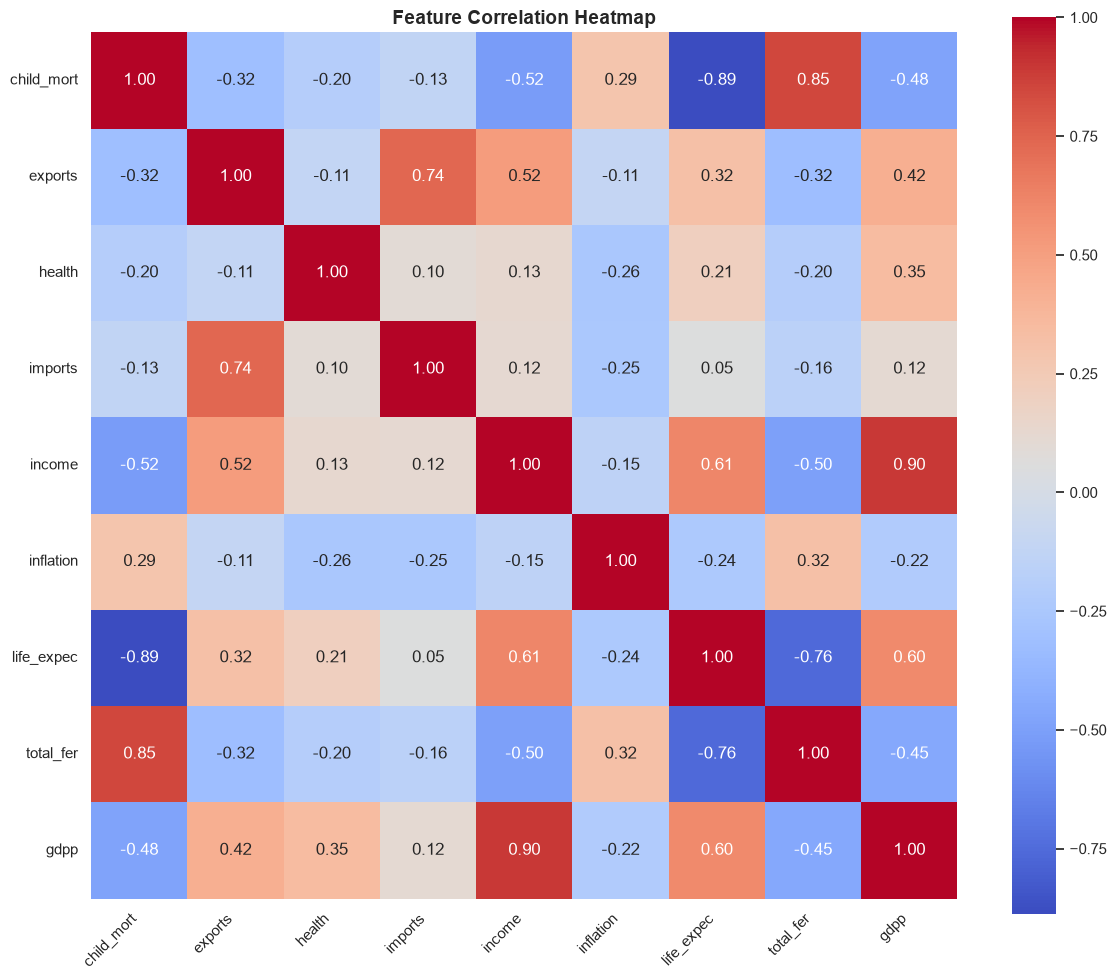

In [7]:
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    cbar=True,
    square=True,
)

plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


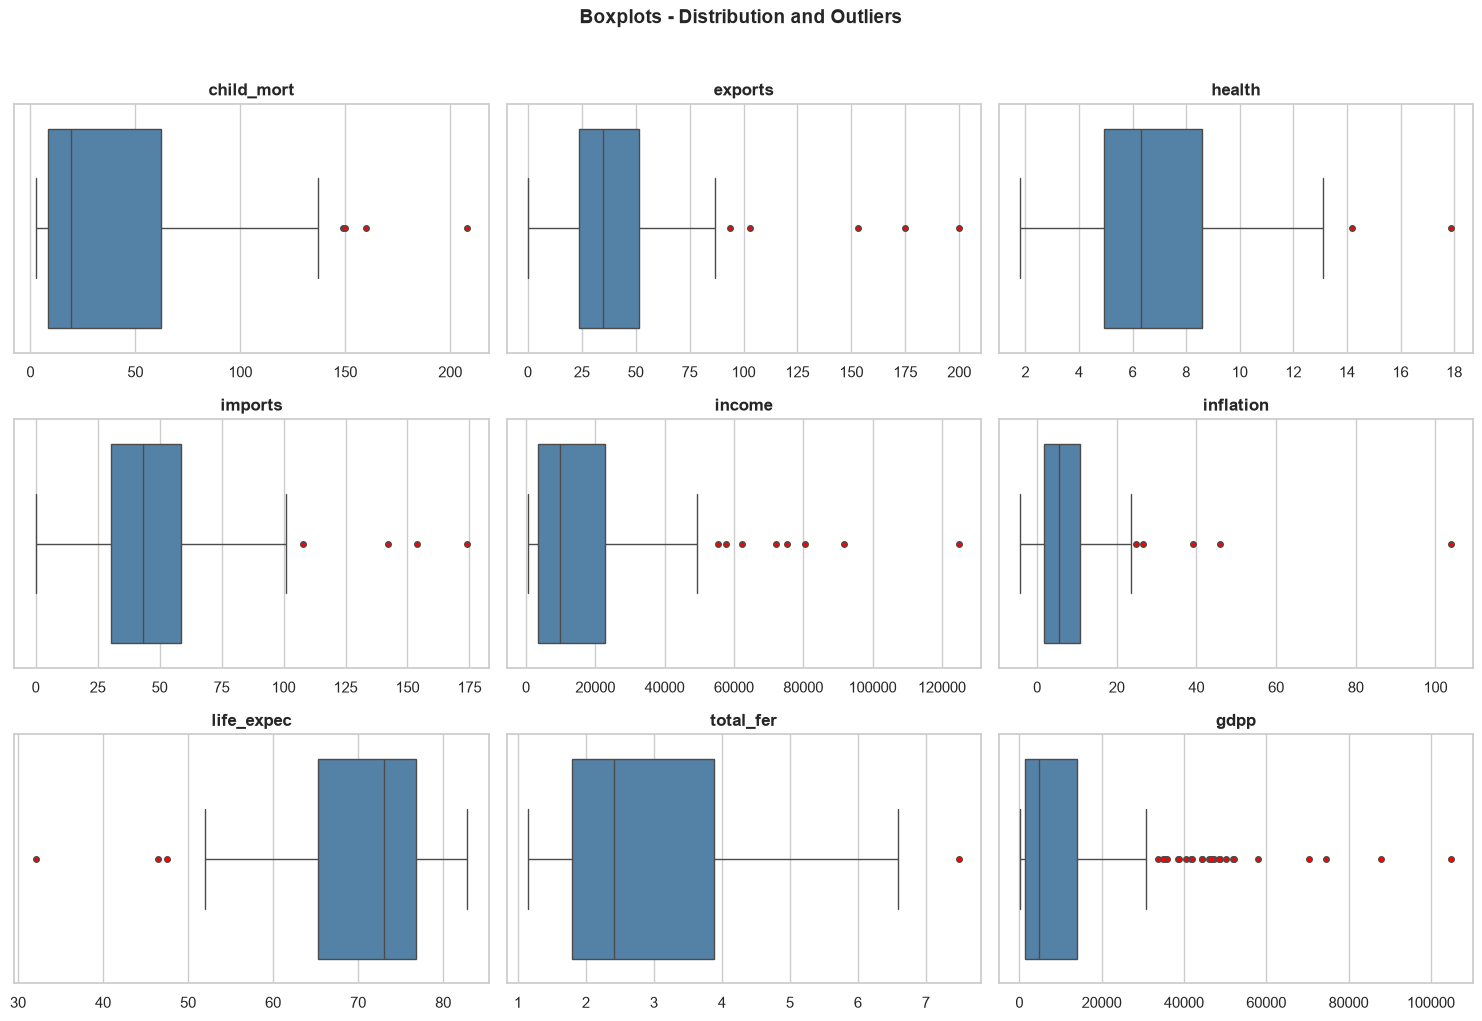


 Outlier count per feature (values beyond 1.5*IQR):
child_mort: 4 outliers
exports: 5 outliers
health: 2 outliers
imports: 4 outliers
income: 8 outliers
inflation: 5 outliers
life_expec: 3 outliers
total_fer: 1 outliers
gdpp: 25 outliers


In [8]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(
        x=df[col],
        ax=axes[i],
        color='steelblue',
        flierprops=dict(marker='o', markerfacecolor='red', markersize=4) 
    )
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Boxplots - Distribution and Outliers', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n Outlier count per feature (values beyond 1.5*IQR):")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))]
    print(f"{col}: {len(outliers)} outliers")

## 8) Feature scaling

Clustering works better when features are on the same scale.

In [9]:
features = df.drop(columns=['country'], errors='ignore')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)
X_scaled.shape

(167, 9)

## 9) K-Means: Elbow method

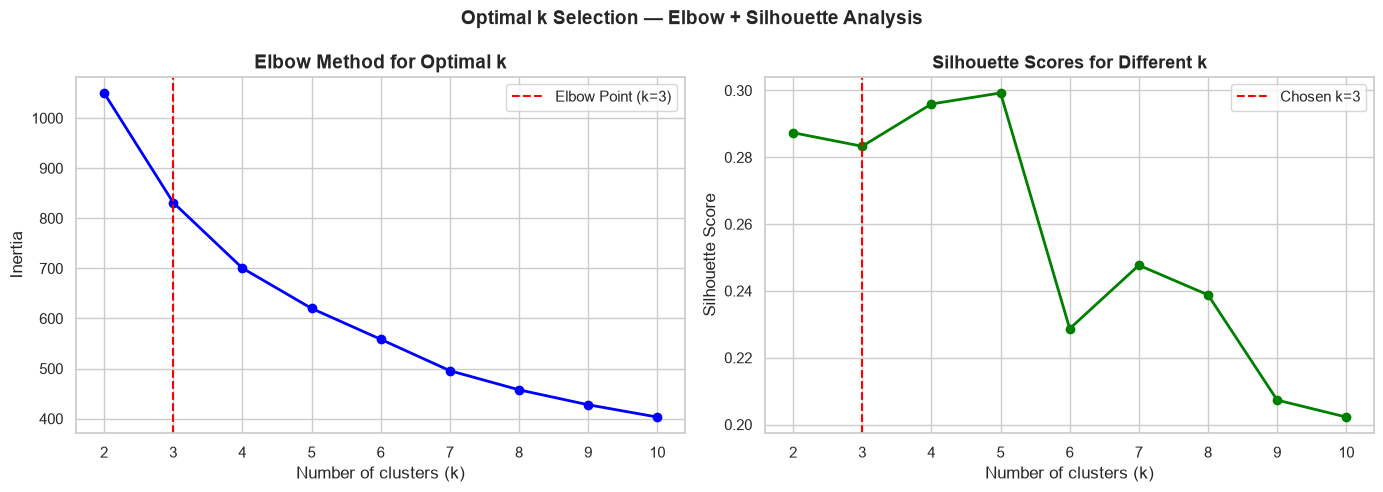


k-value Analysis Summary:
   k      Inertia   Silhouette
------------------------------
   2       1050.2       0.2874
   3        831.4       0.2833 ← chosen
   4        700.5       0.2960
   5        620.2       0.2993
   6        558.5       0.2287
   7        495.8       0.2477
   8        457.6       0.2388
   9        427.8       0.2073
  10        403.2       0.2022


In [10]:
inertias = []
sil_scores = []
k_values = range(2, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)

    inertias.append(model.inertia_)
    sil_scores.append(silhouette_score(X_scaled, model.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_values), inertias, marker='o', color='blue',linewidth=2)
axes[0].axvline(x=3, color='red', linestyle='--', label='Elbow Point (k=3)')
axes[0].set_title('Elbow Method for Optimal k', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].legend()

axes[1].plot(list(k_values), sil_scores, marker='o', color='green', linewidth=2)
axes[1].axvline(x=3, color='red', linestyle='--', label='Chosen k=3')
axes[1].set_title('Silhouette Scores for Different k', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

plt.suptitle('Optimal k Selection — Elbow + Silhouette Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nk-value Analysis Summary:")
print(f"{'k':>4} {'Inertia':>12} {'Silhouette':>12}")
print("-" * 30)
for k, inertia, sil in zip(k_values, inertias, sil_scores):
    marker = " ← chosen" if k == 3 else ""
    print(f"{k:>4} {inertia:>12.1f} {sil:>12.4f}{marker}")

## 10) Train K-Means

In [11]:
best_k = 3  # change after checking the elbow plot
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

sil_score = silhouette_score(X_scaled, df['kmeans_cluster'])
print(f"Silhouette Score(k={best_k}): {sil_score:.4f}")

print("\nNumber of countries per cluster:")
print(df['kmeans_cluster'].value_counts().sort_index().to_string())

df[['country', 'kmeans_cluster']].head() if 'country' in df.columns else df[['kmeans_cluster']].head()

Silhouette Score(k=3): 0.2833

Number of countries per cluster:
kmeans_cluster
0    36
1    47
2    84


,country,kmeans_cluster
0,Afghanistan,1
1,Albania,2
2,Algeria,2
3,Angola,1
4,Antigua and Barbuda,2


## 11) Try DBSCAN

In [12]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

counts = df['dbscan_cluster'].value_counts().sort_index()
n_clusters = len(counts[counts.index != -1])
n_noise = counts.get(-1, 0)

print(f"\nDBSCAN Clustering Results:")
print(f"Number of clusters found: {n_clusters}")
print(f"Number of noise points: {n_noise}")

noise_countries = df[df['dbscan_cluster'] == -1]['country'].tolist()
print(f"Countries identified as noise: {noise_countries}")
print(f"\nOutlier countries identified by DBSCAN ({len(noise_countries)}):")


DBSCAN Clustering Results:
Number of clusters found: 1
Number of noise points: 30
Countries identified as noise: ['Angola', 'Brunei', 'Central African Republic', 'Congo, Dem. Rep.', 'Congo, Rep.', 'Equatorial Guinea', 'Gabon', 'Haiti', 'Iraq', 'Ireland', 'Kiribati', 'Kuwait', 'Lesotho', 'Liberia', 'Luxembourg', 'Malta', 'Micronesia, Fed. Sts.', 'Mongolia', 'Nigeria', 'Norway', 'Qatar', 'Rwanda', 'Seychelles', 'Sierra Leone', 'Singapore', 'South Africa', 'Timor-Leste', 'Turkmenistan', 'United States', 'Venezuela']

Outlier countries identified by DBSCAN (30):


## 12) PCA visualization

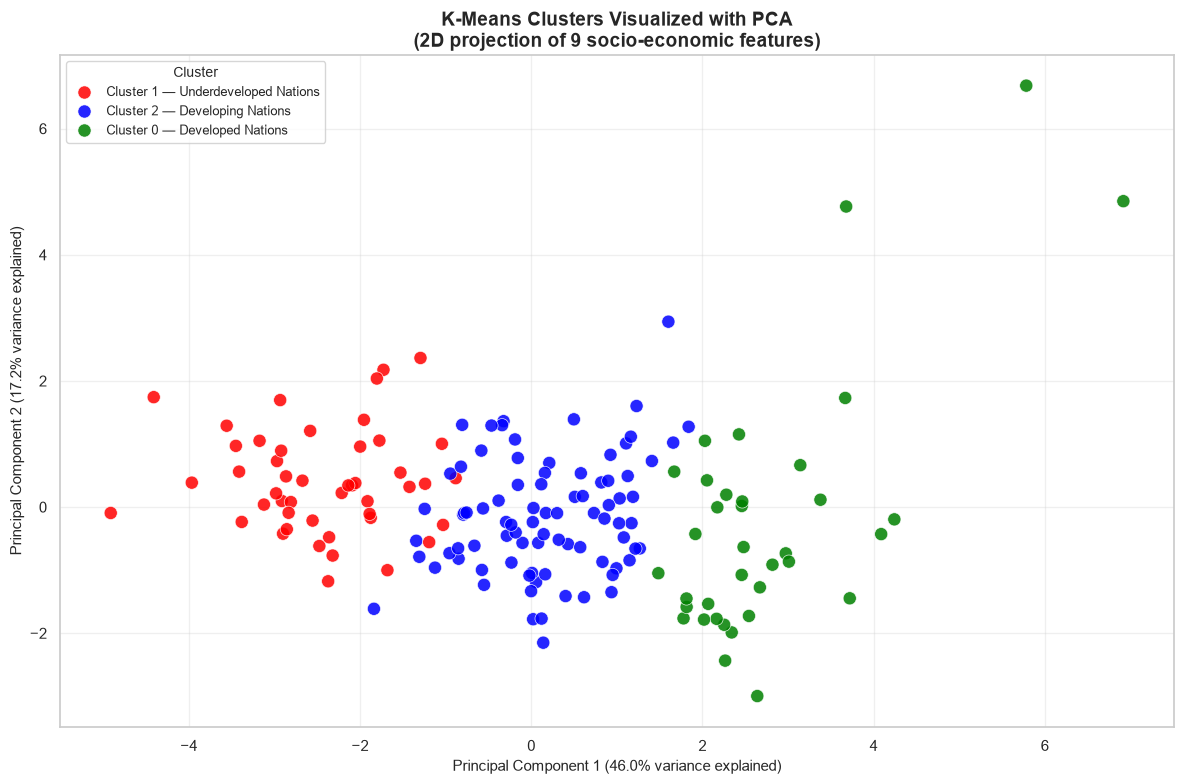

In [13]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_


viz = pd.DataFrame({
    'pca1': X_pca[:, 0],
    'pca2': X_pca[:, 1],
    'cluster': df['kmeans_cluster'].astype(str),
    'Country': df['country']
})

cluster_labels = {
    '0': 'Cluster 0 — Developed Nations',
    '1': 'Cluster 1 — Underdeveloped Nations',
    '2': 'Cluster 2 — Developing Nations'
}
viz['Cluster Label'] = viz['cluster'].map(cluster_labels)

plt.figure(figsize=(12, 8))

colors = {
    'Cluster 0 — Developed Nations': 'green',
    'Cluster 1 — Underdeveloped Nations': 'red',
    'Cluster 2 — Developing Nations': 'blue'
}

sns.scatterplot(
    data=viz,
    x='pca1',
    y='pca2',
    hue='Cluster Label',
    palette=colors,
    s=90,
    alpha=0.85,
    edgecolor='white',
    linewidth=0.5
)

plt.title('K-Means Clusters Visualized with PCA\n'
          '(2D projection of 9 socio-economic features)',
          fontsize=14, fontweight='bold')
plt.xlabel(f'Principal Component 1 ({explained[0]*100:.1f}% variance explained)',
           fontsize=11)
plt.ylabel(f'Principal Component 2 ({explained[1]*100:.1f}% variance explained)',
           fontsize=11)
plt.legend(title='Cluster', fontsize=9, title_fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 13) Cluster profiling

In [14]:
profile = df.groupby('kmeans_cluster')[numeric_cols].mean().round(2)
profile.index = ['Cluster 0', 'Cluster 1', 'Cluster 2']

print("=" * 60)
print("CLUSTER PROFILES — Mean Feature Values per Cluster")
print("=" * 60)

display(profile.T)

print("\nKey Indicators for Cluster Identification:")
print(f"{'Cluster':<12} {'child_mort':>12} {'gdpp':>12} {'life_expec':>12} {'income':>12}")
print("-" * 52)
for cluster in profile.index:
    print(f"{cluster:<12} "
          f"{profile.loc[cluster,'child_mort']:>12.2f} "
          f"{profile.loc[cluster,'gdpp']:>12.2f} "
          f"{profile.loc[cluster,'life_expec']:>12.2f} "
          f"{profile.loc[cluster,'income']:>12.2f}")
          

CLUSTER PROFILES — Mean Feature Values per Cluster


,Cluster 0,Cluster 1,Cluster 2
child_mort,5.00,92.96,21.93
exports,58.74,29.15,40.24
health,8.81,6.39,6.20
imports,51.49,42.32,47.47
income,45672.22,3942.40,12305.60
inflation,2.67,12.02,7.60
life_expec,80.13,59.19,72.81
total_fer,1.75,5.01,2.31
gdpp,42494.44,1922.38,6486.45



Key Indicators for Cluster Identification:
Cluster        child_mort         gdpp   life_expec       income
----------------------------------------------------
Cluster 0            5.00     42494.44        80.13     45672.22
Cluster 1           92.96      1922.38        59.19      3942.40
Cluster 2           21.93      6486.45        72.81     12305.60


In [ ]:

profile = df.groupby('kmeans_cluster')[numeric_cols].mean().round(2)
profile.index = ['Cluster 0', 'Cluster 1', 'Cluster 2']

display(profile.T)

# Key indicators to identify cluster identity
print("\nKey Indicators:")
print(f"{'Cluster':<12} {'child_mort':>12} {'gdpp':>12} {'life_expec':>12} {'income':>12}")
print("-" * 52)
for cluster in profile.index:
    print(f"{cluster:<12} "
          f"{profile.loc[cluster, 'child_mort']:>12.2f} "
          f"{profile.loc[cluster, 'gdpp']:>12.2f} "
          f"{profile.loc[cluster, 'life_expec']:>12.2f} "
          f"{profile.loc[cluster, 'income']:>12.2f}")

# Sample countries per cluster
print("\nSample Countries per Cluster:")
for c in [0, 1, 2]:
    countries = df[df['kmeans_cluster'] == c]['country'].tolist()
    print(f"\n  Cluster {c} ({len(countries)} countries):")
    print(f"  {', '.join(countries[:8])}...")

,Cluster 0,Cluster 1,Cluster 2
child_mort,5.00,92.96,21.93
exports,58.74,29.15,40.24
health,8.81,6.39,6.20
imports,51.49,42.32,47.47
income,45672.22,3942.40,12305.60
inflation,2.67,12.02,7.60
life_expec,80.13,59.19,72.81
total_fer,1.75,5.01,2.31
gdpp,42494.44,1922.38,6486.45



Key Indicators:
Cluster        child_mort         gdpp   life_expec       income
----------------------------------------------------
Cluster 0            5.00     42494.44        80.13     45672.22
Cluster 1           92.96      1922.38        59.19      3942.40
Cluster 2           21.93      6486.45        72.81     12305.60

Sample Countries per Cluster:

  Cluster 0 (36 countries):
  Australia, Austria, Bahrain, Belgium, Brunei, Canada, Cyprus, Czech Republic...

  Cluster 1 (47 countries):
  Afghanistan, Angola, Benin, Botswana, Burkina Faso, Burundi, Cameroon, Central African Republic...

  Cluster 2 (84 countries):
  Albania, Algeria, Antigua and Barbuda, Argentina, Armenia, Azerbaijan, Bahamas, Bangladesh...


## 14) Final insights

Write 3 to 5 observations about the clusters:
- Which cluster has high child mortality?
- Which cluster has high income and gdpp?
- Which cluster looks underdeveloped?
- Which countries should be prioritized for aid?


Observation 1 - Cluster 1 has the highest child-Mortality at 92.96 deaths per 1000 live births nearly 18x highest than cluster 0(5.00).These countries also have lowest life expectancy(59.19 years) and the highest fertility rate (5.01 children per woman). Countries in this cluster are the most underdeveloped nations and should be at the highest priority for international aid.

Observation 2 - Cluster 0 contains the world's most developed nations with a mean GDP per capita of $42,494 and mean income of $45,672 - which is over 11 times higher than cluster 1. These countries also have the highest life expectancy (80.13 years) and lowest child mortality(5.00).

Observation 3 - Cluster 2 contains the developing nations around the world.
This clusters contains the most number of countries (84 countries) at intermediate development. Mean GDP per capita is $6,486 and has life expectancy of 72.81 years. These countries have made significant progress compared to cluster 1 but have not yet attended the benchmark of economic development and health set by the cluster 0.

Observation 4 - By looking at facts and figures cluster 1 seems to underdeveloped. Inflation is the highest in this group of nations with a mean inflation rate of 12.02% which is nearly 4.5 times higher than cluster 0(2.67%) and it is also signifiantly higher than cluster 2(7.60%). High inflation makes it harder for citizens to afford basic needs like Medical treatments, food, and primary education. 

Observation 5 - Based on the result , countries in cluster 1 should be at the highest priority for international aid. 
Additionally , DBSCAN flagged 30 countries as noise points.these countries does not belong to any cluster. These countries are either the richest nations or conflict affected nations. The conflict affected nations have weak healthcare systems and extreme wealth inequality.
These nations require specialized support rather than just standard aid programs. 

